# 1584. Min Cost to Connect All Points

Hint
You are given an array points representing integer coordinates of some points on a 2D-plane, where **points[i] = [xi, yi]**.

The cost of connecting two points **[xi, yi]** and **[xj, yj]** is the manhattan distance between them: **|xi - xj| + |yi - yj|**, where **|val|** denotes the absolute value of val.

Return the minimum cost to make all points connected. All points are connected if there is exactly one simple path between any two points.


Example 1:


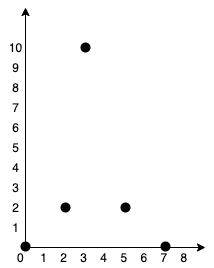

Input: points = [[0,0],[2,2],[3,10],[5,2],[7,0]]
Output: 20
Explanation: 

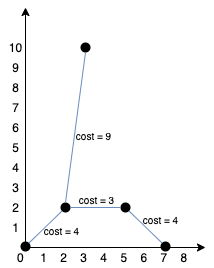

We can connect the points as shown above to get the minimum cost of 20.
Notice that there is a unique path between every pair of points.

 

# Live Code: Entendendo o Problema e a Solução Passo a Passo
 
## Especificação do Problema
- Dado um conjunto de pontos em um plano 2D, queremos conectar todos eles com o menor custo possível.
- O custo para conectar dois pontos é a distância de Manhattan entre eles: $|x_1 - x_2| + |y_1 - y_2|$.
- Todos os pontos devem estar conectados, ou seja, deve existir um caminho entre qualquer par de pontos.

## Casos de Borda (Edge Cases)
- Apenas 1 ponto: custo é 0 (nada para conectar).
- Todos os pontos na mesma posição: custo é 0.
- Pontos alinhados em linha reta: solução é conectar em sequência.
- Pontos formando um quadrado ou espalhados: algoritmo deve escolher as conexões mais baratas.

## Desenho da Iteração (Exemplo Visual)
Suponha os pontos:
- A (0,0)
- B (2,2)
- C (3,10)
- D (5,2)
- E (7,0)

Visualmente:
```
A       B     C
*-------*     *
         \   /
          *-*
         D   E
```

### Como o algoritmo conecta:
1. Começa em qualquer ponto (ex: A).
2. Procura o ponto mais próximo ainda não conectado (menor custo).
3. Conecta e repete até todos estarem ligados.
4. Sempre escolhe a conexão mais barata disponível.

## Lógica do Algoritmo (Explicação Simples)
- Usamos uma "fila de prioridade" (heap) para sempre pegar a conexão mais barata.
- Cada vez que conectamos um novo ponto, atualizamos as opções de conexões para os pontos restantes.
- O processo termina quando todos os pontos estão conectados.

## Resumindo:
- É como construir estradas entre cidades, sempre escolhendo a estrada mais barata que liga uma cidade nova à rede já conectada.
- No final, todas as cidades estão ligadas gastando o mínimo possível.

---
Se quiser, rode o código acima com exemplos diferentes e veja como as conexões mudam!

In [ ]:
# Solução comentada passo a passo
from typing import List
import heapq  # heapq é uma biblioteca que implementa uma fila de prioridade (min-heap) eficiente

class Solution:
    def minCostConnectPoints(self, points: List[List[int]]) -> int:
        total_points = len(points)  # Número total de pontos
        total_cost = 0  # Custo total para conectar todos os pontos
        seen = set()  # Conjunto para marcar os pontos já conectados

        # min_heap é uma fila de prioridade que sempre retorna o menor custo disponível.
        # Começamos com o ponto 0 e custo 0: (custo, índice_do_ponto) o proprio ponto
        min_heap = [(0, 0)]

        # Enquanto não conectarmos todos os pontos
        while len(seen) < total_points:
            # Pegamos o ponto com o menor custo para conectar
            dist, i = heapq.heappop(min_heap)

            # Se já conectamos esse ponto, pulamos
            if i in seen:
                continue

            # Marcamos o ponto como conectado
            seen.add(i)
            # Adicionamos o custo para conectar esse ponto
            total_cost += dist

            xi, yi = points[i]  # Coordenadas do ponto atual

            # Para cada ponto ainda não conectado, calculamos o custo de conectar a partir do ponto atual
            for j in range(total_points):
                if j in seen:
                    continue
                xj, yj = points[j]
                # Distância de Manhattan entre os pontos i e j
                neighbor_dist = abs(xj - xi) + abs(yj - yi)
                # Adicionamos esse custo na fila de prioridade
                heapq.heappush(min_heap, (neighbor_dist, j))

        # Quando todos os pontos estiverem conectados, retornamos o custo total
        return total_cost  # Complexidade: O(n^2 log n)

# Explicação geral:
# - Usamos uma abordagem parecida com o algoritmo de Prim para encontrar a Árvore Geradora Mínima (MST).
# - heapq é usado para sempre escolher o próximo ponto a ser conectado com o menor custo possível.
# - seen garante que não conectamos o mesmo ponto mais de uma vez.
# - A cada iteração, conectamos um novo ponto e atualizamos os custos para os pontos restantes.
# - O processo termina quando todos os pontos estão conectados.

In [5]:
input = [[0,0],[2,2],[3,10],[5,2],[7,0]]

# Corrigido: precisamos criar uma instância da classe Solution para chamar o método de instância
sol = Solution()
min_cost = sol.minCostConnectPoints(input)
print(min_cost)

20
